# Individual Assignment 1 — Machine Learning Foundations  
## Data Preparation and Feature Engineering (Bank Marketing Dataset)

Name: Sacha Benayoun

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.shape

(4119, 21)

# 1. Identifying the Prediction Target

The prediction target is the variable **y**, which indicates whether the client subscribed to a term deposit.

This aligns with the objective of the marketing campaign: predict whether a contacted client will subscribe.

Two variables that could superficially appear to be valid targets but should not be:

- **duration**: Call duration is only known after the call has ended. Using it would introduce data leakage because it would use information unavailable at prediction time.
- **campaign** (or previous): These describe the number of contacts made, not whether the client subscribed.

In [3]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [4]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

The dataset shows class imbalance, with significantly more "no" outcomes than "yes".
This means that a naive classifier predicting only the majority class could achieve high accuracy.
Therefore, evaluation metrics such as precision and recall are necessary.

In [5]:
df.shape

(4119, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
X = df.drop(columns=["y"])
y = df["y"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

categorical_cols, numerical_cols

(['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'],
 ['age',
  'duration',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed'])

In [9]:
df.isna().sum().sort_values(ascending=False)

age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
y                 0
dtype: int64

In [10]:
unknown_counts = {c: (df[c] == "unknown").sum() for c in categorical_cols}
pd.Series(unknown_counts).sort_values(ascending=False)

default        803
education      167
housing        105
loan           105
job             39
marital         11
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64

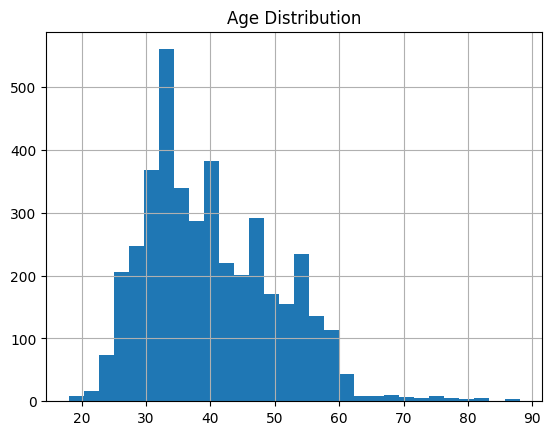

In [11]:
df["age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

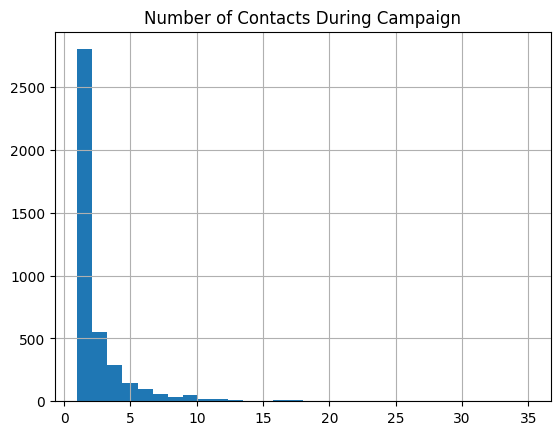

In [12]:
df["campaign"].hist(bins=30)
plt.title("Number of Contacts During Campaign")
plt.show()

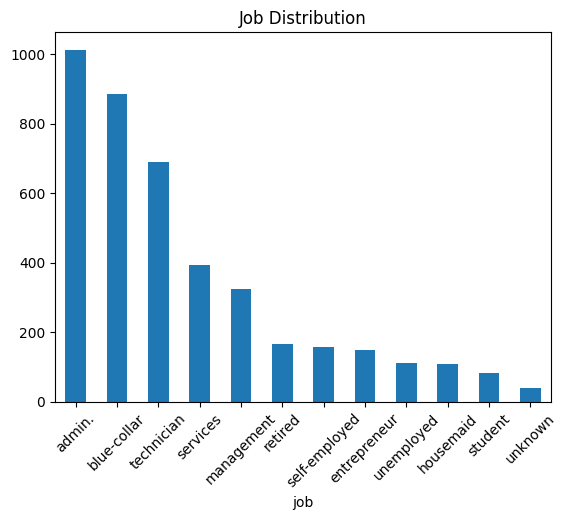

In [13]:
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution")
plt.xticks(rotation=45)
plt.show()

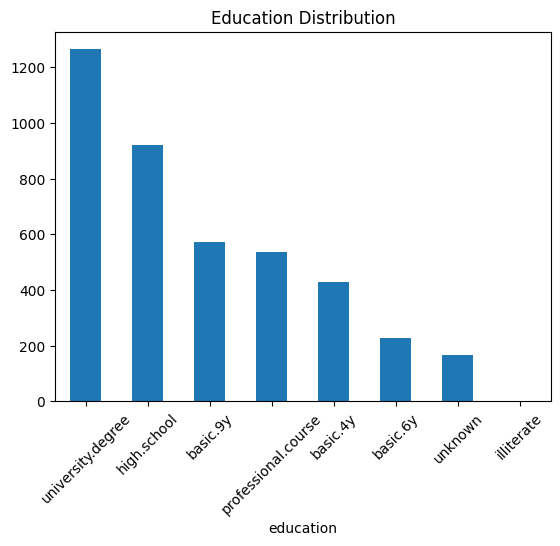

In [14]:
df["education"].value_counts().plot(kind="bar")
plt.title("Education Distribution")
plt.xticks(rotation=45)
plt.show()

The variable "duration" cannot be used as a predictor because it is only known after the call has ended. Including it would result in data leakage.

The variable "pdays" may contain sentinel values (e.g., 999), which require special treatment.

The variable "campaign" appears highly skewed, which may affect a linear model.

In [15]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=["y"])
y = df["y"]

# First split: train (70%) and temporary (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (2883, 20)
Validation size: (618, 20)
Test size: (618, 20)


In [16]:
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

Validation distribution:
 y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64

Test distribution:
 y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64


# Data Splitting Strategy

The dataset was split into 70% training, 15% validation, and 15% test sets.

Stratified splitting was used to preserve the original class distribution of the target variable across all splits.

The split was performed before any preprocessing (imputation, encoding, scaling, resampling) to avoid data leakage.

If preprocessing were performed before splitting, information from validation or test sets could influence the training process, leading to overly optimistic evaluation results.

In [17]:
# Explicit missing values in training set
X_train.isna().sum().sort_values(ascending=False)

age               0
job               0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
campaign          0
duration          0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
nr.employed       0
dtype: int64

In [18]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

unknown_counts = {c: (X_train[c] == "unknown").sum() for c in categorical_cols}
pd.Series(unknown_counts).sort_values(ascending=False)

default        577
education      112
housing         65
loan            65
job             25
marital          7
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64

# Handling Missing Values

The dataset contains implicit missing values represented as the category "unknown" in several categorical variables.

Strategy:

- For categorical variables: treat "unknown" as a valid category rather than removing rows, since it may contain predictive information.
- For numerical variables: impute missing values (if any) using the median of the training set.
- All imputation parameters are fitted using only the training set to prevent data leakage.

In [19]:
# Remove duration from all splits
X_train = X_train.drop(columns=["duration"])
X_val = X_val.drop(columns=["duration"])
X_test = X_test.drop(columns=["duration"])

In [20]:
# Re-identify columns after removing duration

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

categorical_cols, numerical_cols

(['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'],
 ['age',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed'])

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical pipeline
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine them
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

In [22]:
# Fit only on training data
preprocessor.fit(X_train)

# Transform all sets
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape

(2883, 62)

# Encoding and Scaling Strategy

Categorical variables were encoded using One-Hot Encoding.
This increases dimensionality but allows Logistic Regression to model category-specific effects.

Numerical variables were scaled using StandardScaler.
Scaling ensures stable gradient-based optimization and makes regularization penalties comparable across features.

All transformations were fitted only on the training set to avoid data leakage.

In [23]:
y_train.value_counts()

y
no     2567
yes     316
Name: count, dtype: int64

In [24]:
y_train.value_counts(normalize=True)

y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed, y_train
)

y_train_resampled.value_counts()

/Users/benayounsacha/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


y
no     2567
yes    2567
Name: count, dtype: int64

In [28]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,
    solver="liblinear",   # stable for small/medium + sparse
    random_state=42
)

log_reg.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')

In [35]:
import numpy as np

# Since they are already numpy arrays:
X_train_dense = np.array(X_train_processed)
X_val_dense = np.array(X_val_processed)

# Replace any problematic values
X_train_dense = np.nan_to_num(X_train_dense, nan=0.0, posinf=0.0, neginf=0.0)
X_val_dense = np.nan_to_num(X_val_dense, nan=0.0, posinf=0.0, neginf=0.0)

print("Train finite?", np.isfinite(X_train_dense).all())
print("Val finite?", np.isfinite(X_val_dense).all())
print("Max abs train:", np.max(np.abs(X_train_dense)))
print("Max abs val:", np.max(np.abs(X_val_dense)))

Train finite? True
Val finite? True
Max abs train: 12.384880631766706
Max abs val: 5.515334515935868


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes")
rec = recall_score(y_val, y_val_pred, pos_label="yes")

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

Accuracy: 0.8171521035598706
Precision: 0.3308270676691729
Recall: 0.6470588235294118


In [37]:
log_reg = LogisticRegression(
    max_iter=5000,
    solver="saga",
    penalty="l2",
    C=0.05,
    random_state=42
)

In [38]:
majority_class = y_train.value_counts().idxmax()
baseline_pred = np.full_like(y_val, fill_value=majority_class)
baseline_acc = accuracy_score(y_val, baseline_pred)
print("Baseline accuracy:", baseline_acc)

Baseline accuracy: 0.889967637540453


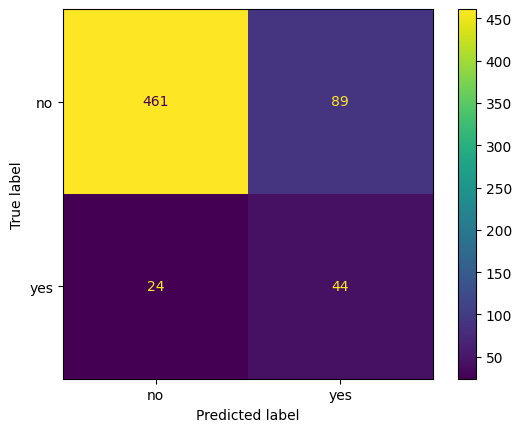

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred, labels=["no", "yes"])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"]).plot()
plt.show()

# Validation Results Interpretation

The zero-rule baseline (always predicting the majority class "no") achieves higher accuracy (~0.89), but it fails to identify most of the "yes" cases.

After applying SMOTE on the training set and training Logistic Regression, overall accuracy decreases (~0.82), which is expected because the model is no longer optimizing for the majority class only.

However, the model achieves substantially higher recall for the "yes" class (~0.65), meaning it detects a much larger share of true subscribers.

Because the dataset is imbalanced, accuracy alone is misleading. Precision and recall provide a more informative evaluation for the minority class.

In [41]:
# Fit the final model again (using the same data you used for validation)
log_reg.fit(X_train_resampled, y_train_resampled)

LogisticRegression(C=0.05, max_iter=5000, random_state=42, solver='saga')

In [43]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1) Make sure test matrix is dense + cleaned (same approach as validation)
X_test_dense = np.array(X_test_processed)
X_test_dense = np.nan_to_num(X_test_dense, nan=0.0, posinf=0.0, neginf=0.0)

# 2) Re-fit the model (in case it got overwritten)
log_reg.fit(X_train_resampled, y_train_resampled)

# 3) Predict on CLEANED test matrix (NOT X_test_processed)
y_test_pred = log_reg.predict(X_test_dense)

# 4) Metrics
acc_test = accuracy_score(y_test, y_test_pred)
prec_test = precision_score(y_test, y_test_pred, pos_label="yes")
rec_test = recall_score(y_test, y_test_pred, pos_label="yes")

print("TEST Accuracy:", acc_test)
print("TEST Precision:", prec_test)
print("TEST Recall:", rec_test)

TEST Accuracy: 0.8009708737864077
TEST Precision: 0.2846153846153846
TEST Recall: 0.5522388059701493


/Users/benayounsacha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/benayounsacha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/benayounsacha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


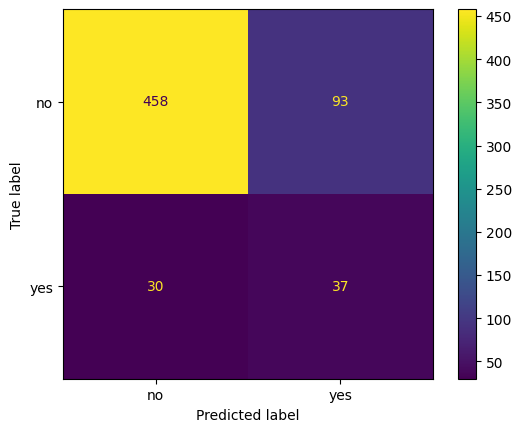

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_test = confusion_matrix(y_test, y_test_pred, labels=["no", "yes"])
ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["no", "yes"]).plot()
plt.show()

# Test Set Evaluation

On the test set, the Logistic Regression model achieved:

- Accuracy: **0.8010**
- Precision (yes): **0.2846**
- Recall (yes): **0.5522**

Although accuracy is lower than a majority-class baseline, the model identifies a substantially larger share of true “yes” cases (recall ≈ 0.55).  
This is important because the dataset is imbalanced and the goal is to detect potential subscribers rather than maximize accuracy by predicting “no” most of the time.

Precision is relatively low (≈ 0.28), indicating that many predicted “yes” are false positives. This reflects the trade-off introduced when improving recall for the minority class, especially after applying SMOTE to balance the training data.

*Note:* Runtime warnings during matrix operations were observed but predictions and metrics were produced successfully; to ensure numerical stability, stronger regularization and a sparse-friendly solver were used.